## HỌ VÀ TÊN: VÕ LÊ PHÚC THỊNH
## MSSV: 2510382

## Chuẩn bị thư viện

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Tải dữ liệu

In [4]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Kích thước tập train: {train_df.shape}")
print(f"Kích thước tập test : {test_df.shape}")
train_df.head()

Kích thước tập train: (8693, 14)
Kích thước tập test : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


## EDA

### Giá trị khuyết

In [22]:
missing_cnt = train_df.isnull().sum()
missing_pct = (train_df.isnull().mean() * 100).round(2)
total_cnt = len(train_df) # Lấy tổng số dòng của dữ liệu

missing_summary = pd.DataFrame({
    "missing_count": missing_cnt,
    "total_count": total_cnt, 
    "missing_%": missing_pct
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_%", ascending=False)
display(missing_summary)

,missing_count,total_count,missing_%
CryoSleep,217,8693,2.50
ShoppingMall,208,8693,2.39
VIP,203,8693,2.34
HomePlanet,201,8693,2.31
Name,200,8693,2.30
Cabin,199,8693,2.29
VRDeck,188,8693,2.16
FoodCourt,183,8693,2.11
Spa,183,8693,2.11
Destination,182,8693,2.09


Tỷ lệ dữ liệu bị khuyết chiếm tỷ lệ nhỏ nên có thể chọn thay thế vào dữ liệu bằng trung vị.

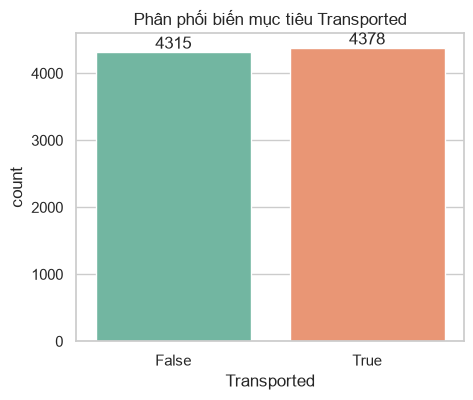

Transported
True     0.504
False    0.496
Name: proportion, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train_df, x="Transported", palette="Set2", ax=ax)
ax.set_title("Phân phối biến mục tiêu Transported")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(train_df["Transported"].value_counts(normalize=True).round(3))

Tỷ lệ phân bỏ hai lớp gần như cân bằng, có thể đánh giá bằng accuracy.

### Biểu đồ các biến phân loại

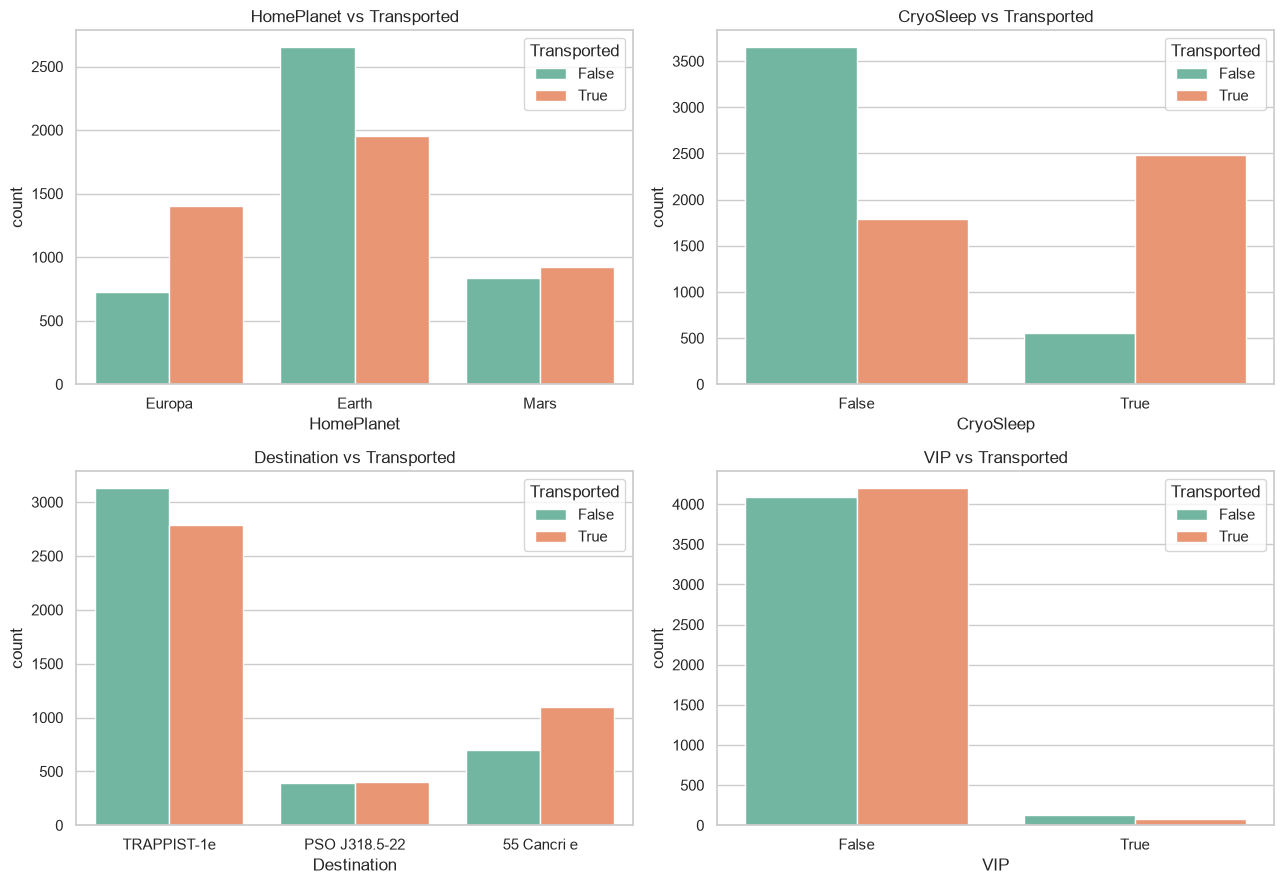

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cat_features = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
for ax, col in zip(axes.flatten(), cat_features):
    sns.countplot(data=train_df, x=col, hue="Transported", ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Transported")
plt.tight_layout()
plt.show()

- `CryoSleep = True` có tỉ lệ `Transported = True` cao nhất cho thấy đây có thể là một trong những đặc trưng quan trọng nhất.
- `HomePlanet` Europa có tỉ lệ transported cao nhất giữa các hành tinh.
- `Destination` cũng có khác biệt rõ giữa các nhóm trong khi `VIP` gần như không phân biệt được hai lớp, có thể là đặc trưng yếu.


### Biểu đồ các biến chi tiêu

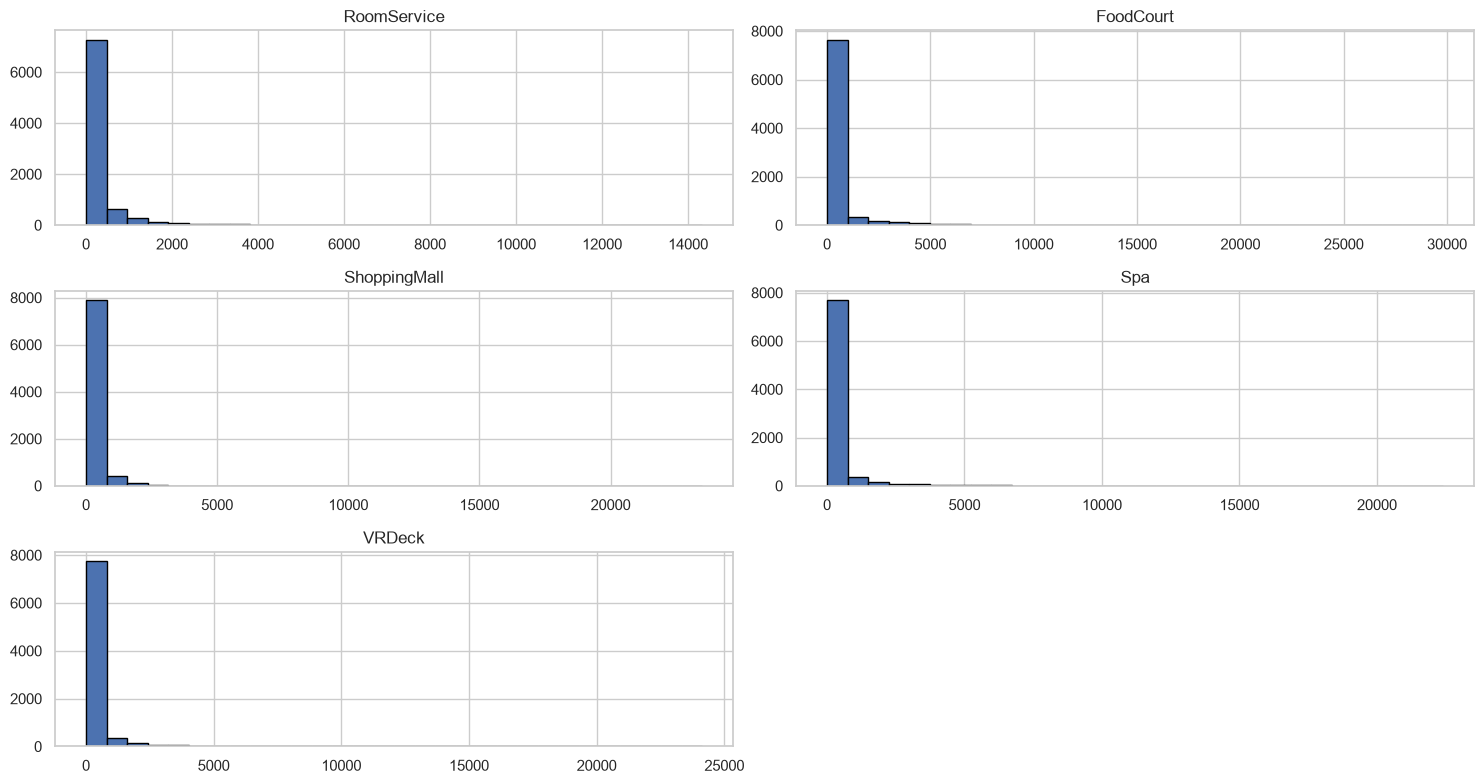

In [24]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train_df[spend_cols].hist(bins=30, figsize=(15, 8), edgecolor="black")
plt.tight_layout()
plt.show()

Phân phối các biến chi tiêu bị lệch phải nặng do đó cần các bước để giảm độ lệch, có thể sử dụng log1p.


### Tương quan các biến số

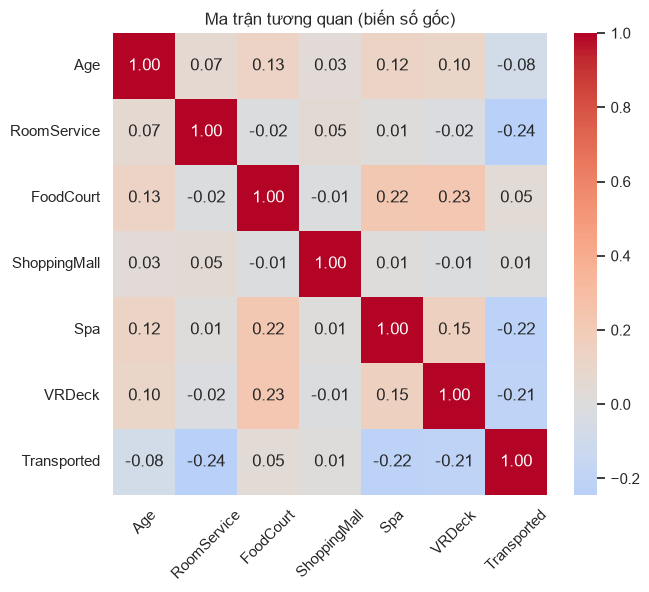

In [25]:
num_preview = ["Age"] + spend_cols
corr = train_df[num_preview + ["Transported"]].assign(Transported=train_df["Transported"].astype(int)).corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan (biến số gốc)")
plt.xticks(rotation=45)
plt.show()

## Preprocessing & Feature Engineering

Các biến chính và kỹ thuật xử lý:

1. `PassengerId` (`gggg_pp`) trích `Group`, từ đó suy ra `GroupSize` (số người đi cùng nhóm) và `IsAlone` (đi một mình hay không)

2. `Cabin` (`deck/num/side`) tách thành `Deck`, `CabinNum`, `Side`

3. `CryoSleep` nếu hành khách có bất kỳ khoản chi tiêu nào > 0 thì chắc chắn `CryoSleep = False`, ngược lại nếu `CryoSleep = True` thì tất cả chi tiêu phải bằng 0.

4. `TotalSpend` (tổng 5 khoản chi tiêu) và `NoSpend` (không chi tiêu gì trùng với `CryoSleep = True`).

5. Tỉ trọng chi tiêu từng dịch vụ (`*_Ratio`) trên tổng chi tiêu.

6. Log-transform (`log1p`) cho các cột chi tiêu để giảm độ lệch phân phối, kéo gần các outlier.

7. Điền khuyết theo `Group` cho `HomePlanet`, `Destination`, `Deck`, `Side` nhiều khả năng các thành viên cùng nhóm đến từ cùng hành tinh hoặc cùng khoang.

8. Điền khuyết  median cho biến số, mode cho biến phân loại.

9. Loại bỏ các cột định danh không mang thông tin dự đoán trực tiếp `PassengerId`, `Name`, `Cabin`, `Group`.

10. One-hot encoding cho các biến phân loại còn lại.

In [26]:
def preprocess_data(df):
    df = df.copy()

    df["Group"] = df["PassengerId"].str.split("_").str[0]
    group_size = df.groupby("Group")["PassengerId"].transform("count")
    df["GroupSize"] = group_size.astype(int)
    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)

    df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)
    df["CabinNum"] = pd.to_numeric(df["CabinNum"], errors="coerce")

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in spend_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    total_spend_raw = df[spend_cols].sum(axis=1, skipna=True)

    
    df.loc[df["CryoSleep"].isnull() & (total_spend_raw > 0), "CryoSleep"] = False
    df["CryoSleep"] = df["CryoSleep"].fillna(True)
    df["CryoSleep"] = df["CryoSleep"].astype(int)

    
    for col in spend_cols:
        df.loc[df["CryoSleep"] == 1, col] = df.loc[df["CryoSleep"] == 1, col].fillna(0)
        df.loc[df["CryoSleep"] == 1, col] = 0

    for col in spend_cols:
        df[col] = df[col].fillna(0)

    df["TotalSpend"] = df[spend_cols].sum(axis=1)
    df["NoSpend"] = (df["TotalSpend"] == 0).astype(int)

    total_safe = df["TotalSpend"].replace(0, np.nan)
    for col in spend_cols:
        df[f"{col}_Ratio"] = (df[col] / total_safe).fillna(0)

    for col in spend_cols + ["TotalSpend"]:
        df[col] = np.log1p(df[col])

    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["CabinNum"] = df["CabinNum"].fillna(df["CabinNum"].median())

    group_impute_cols = ["HomePlanet", "Destination", "Deck", "Side"]
    for col in group_impute_cols:
        df[col] = df.groupby("Group")[col].transform(
            lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
        )

    cat_cols_fill = ["HomePlanet", "Destination", "VIP", "Deck", "Side"]
    for col in cat_cols_fill:
        df[col] = df[col].fillna(df[col].mode()[0])
    df["VIP"] = df["VIP"].astype(int)

    df = df.drop(columns=["PassengerId", "Name", "Cabin", "Group"])

    dummy_cols = ["HomePlanet", "Destination", "Deck", "Side"]
    df = pd.get_dummies(df, columns=dummy_cols, drop_first=True)

    return df



test_passenger_ids = test_df["PassengerId"].copy()
X_all_raw = pd.concat([train_df.drop(columns=["Transported"]), test_df], axis=0, ignore_index=True)
X_all_processed = preprocess_data(X_all_raw)

X = X_all_processed.iloc[: len(train_df)].copy().reset_index(drop=True)
X_test = X_all_processed.iloc[len(train_df):].copy().reset_index(drop=True)
y = train_df["Transported"].astype(int).reset_index(drop=True)

print("X shape:", X.shape, "| X_test shape:", X_test.shape)
X.head()

X shape: (8693, 30) | X_test shape: (4277, 30)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,IsAlone,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_S
0,0,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,...,False,True,True,False,False,False,False,False,False,False
1,0,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,1,1,...,False,True,False,False,False,False,True,False,False,True
2,0,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,2,0,...,False,True,False,False,False,False,False,False,False,True
3,0,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,2,0,...,False,True,False,False,False,False,False,False,False,True
4,0,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,1,1,...,False,True,False,False,False,False,True,False,False,True


In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape} | Validation: {X_val.shape}")

Train: (6954, 30) | Validation: (1739, 30)


## Cài đặt các mô hình Ensemble Learning

So sánh 4 nhóm kỹ thuật ensemble trên cùng một bộ dữ liệu đã xử lý:

| Nhóm | Mô hình |
|---|---|
| **Bagging** | `RandomForestClassifier` | 
| **Boosting** | `GradientBoostingClassifier`, `XGBClassifier`, `HistGradientBoostingClassifier` | 
| **Voting** | `VotingClassifier` | 
| **Stacking** | `StackingClassifier` | 

In [28]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    param_distributions=xgb_param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)

Best XGBoost params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=12, min_samples_split=5, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1,
)

gb_model = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.03, max_depth=4, subsample=0.8,
    random_state=RANDOM_STATE,
)

hgb_model = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE,
)

log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))

voting_model = VotingClassifier(
    estimators=[("rf", rf_model), ("gb", gb_model), ("xgb", xgb_model)],
    voting="soft",
    n_jobs=-1,
)

stacking_model = StackingClassifier(
    estimators=[("rf", rf_model), ("gb", gb_model), ("xgb", xgb_model), ("hgb", hgb_model)],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    passthrough=True,
    n_jobs=-1,
)

models = {
    "Random Forest (Bagging)": rf_model,
    "Gradient Boosting (Boosting)": gb_model,
    "HistGradientBoosting (Boosting)": hgb_model,
    "XGBoost (Boosting)": xgb_model,
    "Voting Classifier (Ensemble)": voting_model,
    "Stacking Classifier (Ensemble)": stacking_model,
}

## Benchmark

Ta đánh giá các mô hình sử dụng 5-fold Stratified Cross-Validation trên toàn bộ tập `X, y`, rồi so sánh accuracy trung bình +- độ lệch chuẩn.

In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    fold_scores = []
    for tr_idx, va_idx in skf.split(X, y):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = model.predict(X.iloc[va_idx])
        fold_scores.append(accuracy_score(y.iloc[va_idx], preds))
    results.append({
        "Model": name,
        "Mean Accuracy": np.mean(fold_scores),
        "Std Dev": np.std(fold_scores),
    })
    print(f"{name:35s} | mean accuracy = {np.mean(fold_scores):.4f}  +- {np.std(fold_scores):.4f}")

df_results = pd.DataFrame(results).sort_values("Mean Accuracy", ascending=False).reset_index(drop=True)
display(df_results)

Random Forest (Bagging)             | mean accuracy = 0.7996  +- 0.0081
Gradient Boosting (Boosting)        | mean accuracy = 0.8096  +- 0.0076
HistGradientBoosting (Boosting)     | mean accuracy = 0.8105  +- 0.0055
XGBoost (Boosting)                  | mean accuracy = 0.8101  +- 0.0064
Voting Classifier (Ensemble)        | mean accuracy = 0.8103  +- 0.0078
Stacking Classifier (Ensemble)      | mean accuracy = 0.8052  +- 0.0091


,Model,Mean Accuracy,Std Dev
0,HistGradientBoosting (Boosting),0.810538,0.005543
1,Voting Classifier (Ensemble),0.810308,0.007775
2,XGBoost (Boosting),0.810078,0.006381
3,Gradient Boosting (Boosting),0.809617,0.007588
4,Stacking Classifier (Ensemble),0.805245,0.009123
5,Random Forest (Bagging),0.799608,0.008102


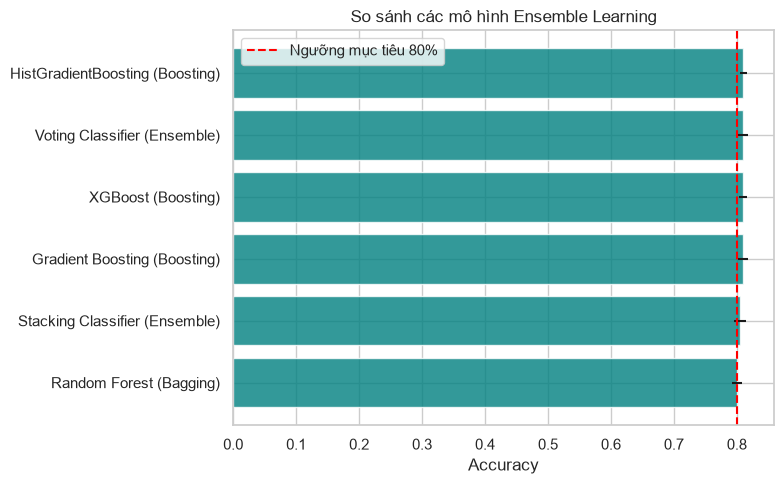

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df_results.sort_values("Mean Accuracy")
bars = ax.barh(order["Model"], order["Mean Accuracy"], xerr=order["Std Dev"], color="teal", alpha=0.8)
ax.axvline(0.80, color="red", linestyle="--", label="Ngưỡng mục tiêu 80%")
ax.set_xlabel("Accuracy")
ax.set_title("So sánh các mô hình Ensemble Learning")
ax.legend()
plt.tight_layout()
plt.show()

## Kiểm tra thêm trên tập Validation

In [36]:
best_model_name = df_results.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
val_preds = best_model.predict(X_val)

print(f"Mô hình tốt nhất theo CV: {best_model_name}")
print(f"Holdout Accuracy: {accuracy_score(y_val, val_preds):.4f}\n")
print(classification_report(y_val, val_preds, target_names=["Not Transported", "Transported"]))

Mô hình tốt nhất theo CV: HistGradientBoosting (Boosting)
Holdout Accuracy: 0.8154

                 precision    recall  f1-score   support

Not Transported       0.82      0.81      0.81       863
    Transported       0.81      0.82      0.82       876

       accuracy                           0.82      1739
      macro avg       0.82      0.82      0.82      1739
   weighted avg       0.82      0.82      0.82      1739



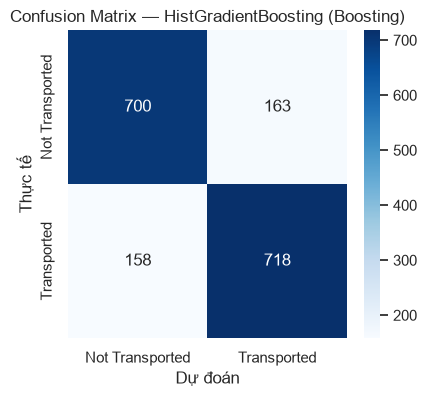

In [18]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Transported", "Transported"],
            yticklabels=["Not Transported", "Transported"])
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## Huấn luyện trên toàn bộ dữ liệu & Xuất file Submission

In [38]:
final_model = models[best_model_name]
final_model.fit(X, y)
test_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Transported": test_preds.astype(bool),
})
submission.to_csv("submission.csv", index=False)

print(f"Đã xuất file submission.csv")


Đã xuất file submission.csv


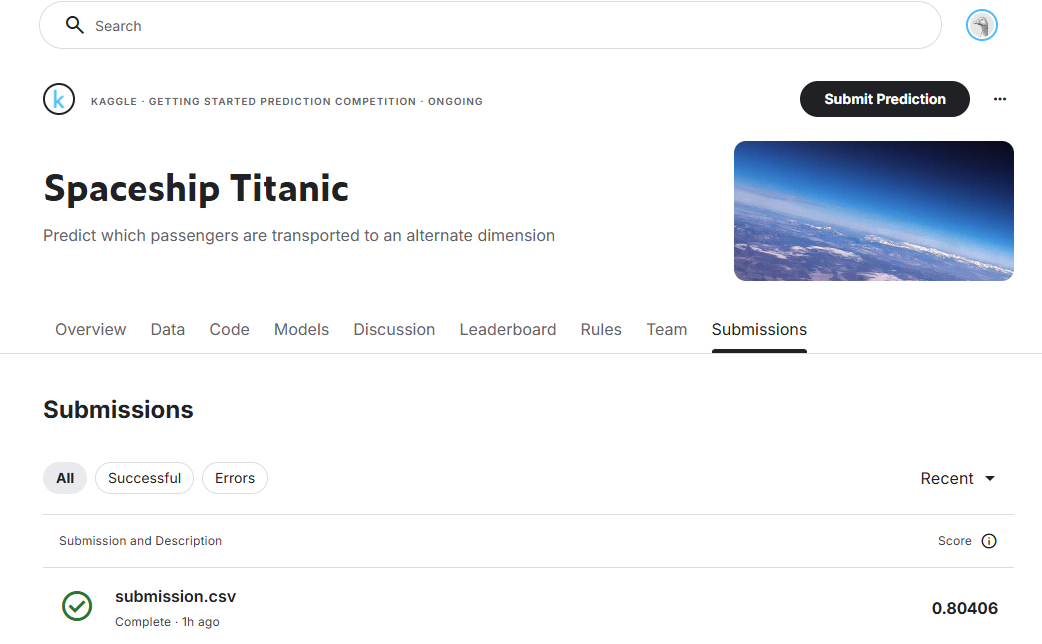